In [ ]:
#%pip install --upgrade omfit_classes

In [ ]:
#%pip install omas

In [ ]:
#%pip install fortranformat

In [3]:
from omfit_classes import omfit_eqdsk

In [4]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.constants import mu_0
import os

In [5]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nhe'][-1,:]
    for i in range(5): #figure it would be crazy to have more than 5 impurities
        try:
            ni_prof_tot += ffile['nz{:d}'.format(i)][-1,:]
        except IndexError:
            continue
    Ti_prof = ffile['ti'][-1,:]
    total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure,rho)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

In [6]:
# FILES
#Change this
sim_index = 0

cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
work_dir = SCAN_dir+'/'+'/work'

fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'

#toric_dir = [f for f in os.listdir(work_dir) if f.startswith('rf_ic_')]
#tfile = work_dir+'/'+toric_dir[0]+'/toric.nc'

print(work_dir)

/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+TGLF/Kr00075_bcfrom2024/SCAN//work


In [29]:
rootgrp = Dataset(ffile)
geqdsk = omfit_eqdsk.OMFITeqdsk(gfile)

## Some ffile variables
Rmaj = rootgrp['r0'][-1]
Bt = float(rootgrp['b0'][-1])
Ip = rootgrp['ip'][-1]
aminor = rootgrp['a0'][-1]

## Calculate Greenwald fraction
nebar = rootgrp['nebar'][-1]
n_Gr = Ip/(np.pi*aminor**2)
f_Gr = nebar/10/n_Gr #divide by 10 to switch from 10^19 to 10^20

## Calculate H factor
#H98y2 = calc_H98y2(geqdsk,rootgrp)

## Calculate Angioni peaking
Gamma_NBI = 0

#Grab profiles
rho = rootgrp['rho'][:]
ne_prof = rootgrp['ne'][-1,:] #10^19/m^3
Te_prof = rootgrp['te'][-1,:] #keV
ni_prof_tot = rootgrp['ni'][-1,:] + rootgrp['nhe'][-1,:]
for i in range(5): #figure it would be crazy to have more than 5 impurities
    try:
        ni_prof_tot += rootgrp['nz{:d}'.format(i)][-1,:]
    except IndexError:
        continue
Ti_prof = rootgrp['ti'][-1,:]
p_prof = (ne_prof*Te_prof+ni_prof_tot*Ti_prof) #should be in keV*10**19/m**3 for Angioni beta equation  #*1602.2 to convert to Pa (multiplication is for from eV to Joules)

##compare pressures from g and f files
#plt.plot(rho,p_prof*1602.2)
#plt.plot(rho_geqdsk,pres_geqdsk)
# pres_f_vol_avg = vol_avg(geqdsk['fluxSurfaces'],p_prof*1602.2,rho)
# print(pres_g_vol_avg)
# print(pres_f_vol_avg)

#Calculate volume averages
ne_vol_avg = vol_avg(geqdsk,ne_prof,rho)
p_vol_avg = vol_avg(geqdsk,p_prof,rho)
Te_vol_avg = vol_avg(geqdsk,Te_prof,rho)
Ti_vol_avg = vol_avg(geqdsk,Ti_prof,rho)

#Calculate regression variables
nu_eff = 0.2*ne_vol_avg*Rmaj/(Te_vol_avg**2) #don't use line average for this density average
beta = 4.02e-3*p_vol_avg/(Bt**2)

n02 = ne_prof[int(0.2*len(ne_prof))]

#Calculate Angioni peaking
npeaking = ufloat(1.347,0.014) - ufloat(0.117,0.005)*np.log(nu_eff) + ufloat(1.331,0.117)*Gamma_NBI - ufloat(4.030,0.810)*beta

n_peak_left = npeaking.nominal_value-npeaking.std_dev
n_peak_right = npeaking.nominal_value+npeaking.std_dev
if n02/ne_vol_avg >= n_peak_left and n02/ne_vol_avg <= n_peak_right:
    print('pass')
else:
    print('fail')
print(ni_prof_tot)

fail
[24.80055085 24.8010058  24.76498149 24.72684807 24.68643245 24.64356272
 24.59822638 24.55104394 24.50279247 24.45425369 24.40622695 24.36013828
 24.31708245 24.27746274 24.24180135 24.21076577 24.184235   24.16105629
 24.1403716  24.12112505 24.10199719 24.08196092 24.06092548 24.03871408
 24.01510903 23.98985088 23.9632112  23.93548171 23.90636644 23.87552213
 23.84255995 23.80614607 23.76514749 23.71948226 23.66911958 23.61407915
 23.55484414 23.49190053 23.42532752 23.35522718 23.28172169 23.20481199
 23.12434629 23.04023952 22.952419   22.86082575 22.76539549 22.66609654
 22.56294142 22.45595809 22.34518946 22.23066514 22.11249735 21.99086757
 21.86596048 21.73796161 21.60713423 21.47367335 21.33766358 21.19919208
 21.05834788 20.91515844 20.76961653 20.62176726 20.47166455 20.31937039
 20.16492883 20.00844298 19.85006263 19.68992806 19.52816808 19.36492963
 19.20033131 19.03443286 18.86726578 18.6988228  18.5290393  18.35775401
 18.18469596 18.00944753 17.83137955 17.649530

[24.80055085 24.8010058  24.76498149 24.72684807 24.68643245 24.64356272
 24.59822638 24.55104394 24.50279247 24.45425369 24.40622695 24.36013828
 24.31708245 24.27746274 24.24180135 24.21076577 24.184235   24.16105629
 24.1403716  24.12112505 24.10199719 24.08196092 24.06092548 24.03871408
 24.01510903 23.98985088 23.9632112  23.93548171 23.90636644 23.87552213
 23.84255995 23.80614607 23.76514749 23.71948226 23.66911958 23.61407915
 23.55484414 23.49190053 23.42532752 23.35522718 23.28172169 23.20481199
 23.12434629 23.04023952 22.952419   22.86082575 22.76539549 22.66609654
 22.56294142 22.45595809 22.34518946 22.23066514 22.11249735 21.99086757
 21.86596048 21.73796161 21.60713423 21.47367335 21.33766358 21.19919208
 21.05834788 20.91515844 20.76961653 20.62176726 20.47166455 20.31937039
 20.16492883 20.00844298 19.85006263 19.68992806 19.52816808 19.36492963
 19.20033131 19.03443286 18.86726578 18.6988228  18.5290393  18.35775401
 18.18469596 18.00944753 17.83137955 17.64953078 17

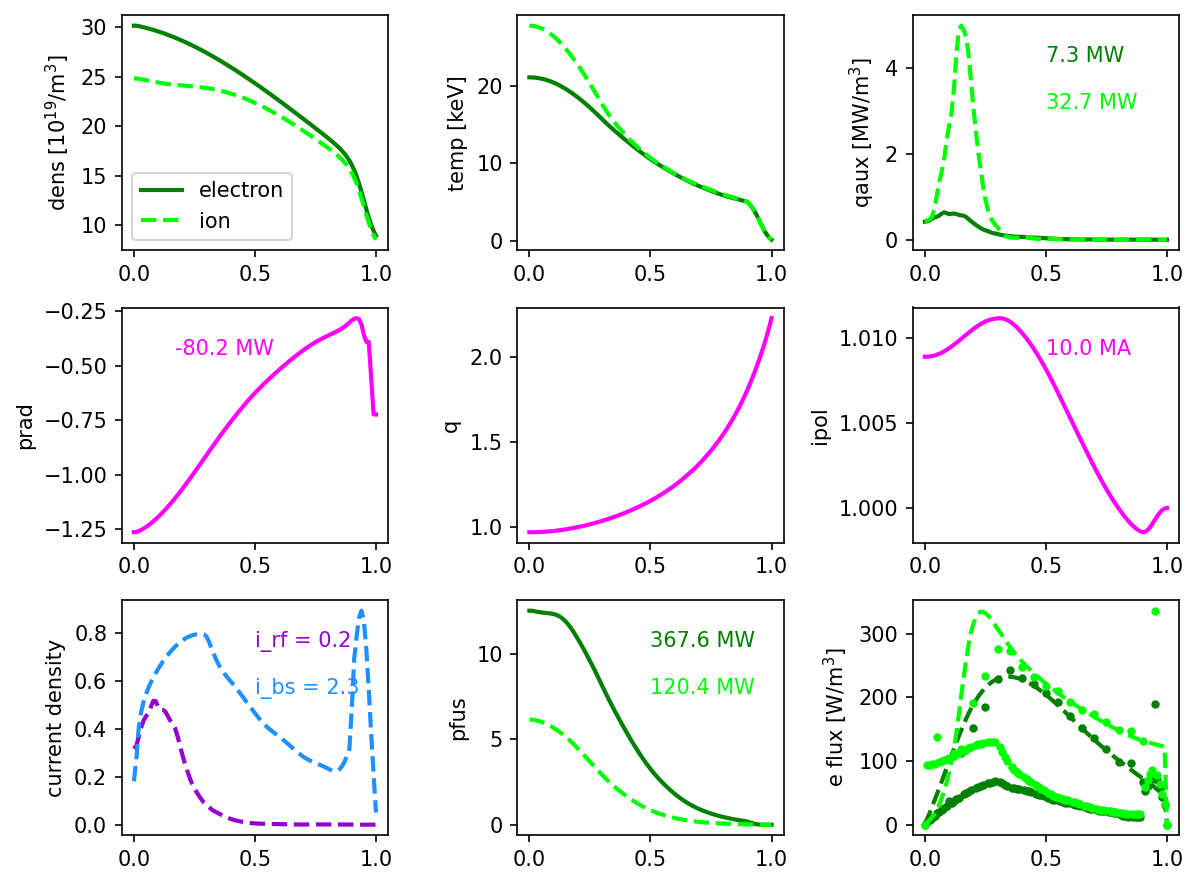

In [31]:
rho = rootgrp['rho'][:]

ne = rootgrp['ne'][-1,:]
nebar = rootgrp['nebar'][-1]
ni = ni_prof_tot # from above
te = rootgrp['te'][-1,:]
teavg = rootgrp['tea'][-1]
ti = rootgrp['ti'][-1,:]
tiavg = rootgrp['tia'][-1]

prfe = rootgrp['pe_rf'][-1,:]
prfe_int = rootgrp['prfe'][-1]
prfi = rootgrp['pi_rf'][-1,:]
prfi_int = rootgrp['prfi'][-1]

prad = rootgrp['p_rad'][-1,:]
prad_int = rootgrp['prad'][-1]

#betan = rootgrp['betan_loc'][-1,:]
#betan = p_vol_avg*1602.2*2*mu_0/Bt**2#*(aminor*Bt/Ip) ##FIXME doesn't make sense #approximate, check which B to use
betan_num = rootgrp['betan'][-1]

ipol = rootgrp['ipol'][-1,:]
ip = rootgrp['ip'][-1]

pfuse = rootgrp['pe_fus'][-1,:]
pfuse_int = rootgrp['pfuse'][-1]
pfusi = rootgrp['pi_fus'][-1,:]
pfusi_int = rootgrp['pfusi'][-1]

q = rootgrp['q'][-1,:]

jbs = rootgrp['j_bs'][-1,:]
ibs = rootgrp['ibs'][-1]
jrf = rootgrp['j_rf'][-1,:]
irf = rootgrp['irf'][-1]
jtot = rootgrp['j_tot'][-1,:]

fluxe = rootgrp['fluxe'][-1,:]
fluxe_exp = rootgrp['fluxe_exp'][-1,:]
fluxi = rootgrp['fluxi'][-1,:]
fluxi_exp = rootgrp['fluxi_exp'][-1,:]

fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) =plt.subplots(3,3,figsize =(8,6),dpi = 150)
lw = 2
c1 = 'green'
c2 = 'lime'
c3 = 'magenta'
c4 = 'darkviolet'
c5 = 'dodgerblue'
c6 = 'cyan'

ax1.plot(rho,ne,color = c1,linewidth = lw,label='electron')
ax1.plot(rho,ni,color = c2,linewidth = lw,linestyle = 'dashed',label='ion')
ax2.plot(rho,te,color = c1,linewidth = lw)
ax2.plot(rho,ti,color = c2,linewidth = lw,linestyle = 'dashed')
ax1.set_ylabel('dens [10$^{19}$/m$^3$]')
ax2.set_ylabel('temp [keV]')
ax1.legend()

ax3.plot(rho,prfe,color = c1,linewidth = lw)
ax3.plot(rho,prfi,color = c2,linewidth = lw,linestyle = 'dashed')
ax4.plot(rho,prad,color = c3,linewidth = lw)
ax4.text(0.2,0.8,'{:.1f} MW'.format(prad_int),color = c3, transform = ax4.transAxes)
ax3.set_ylabel('qaux [MW/m$^3$]')
ax3.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax3.transAxes)
ax3.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax3.transAxes)
ax4.set_ylabel('prad')
#ax4.text(0.5,0.8,'betan = {:.1f}'.format(betan_num),color = c3, transform = ax4.transAxes)

ax5.plot(rho,q,color = c3,linewidth = lw)
ax5.set_ylabel('q')

ax6.plot(rho,ipol,color = c3, linewidth = lw)
ax6.set_ylabel('ipol')
ax6.text(0.5,0.8,'{:.1f} MA'.format(ip),color = c3,transform = ax6.transAxes)

#ax7.plot(rho,jtot,color = c3,linewidth = lw)
ax7.plot(rho,jrf,color = c4,linewidth = lw,linestyle = 'dashed')
ax7.plot(rho,jbs,color = c5, linewidth =lw, linestyle='dashed')
ax7.text(0.5,0.8,'i_rf = {:.1f}'.format(irf),color = c4,transform = ax7.transAxes)
ax7.text(0.5,0.6,'i_bs = {:.1f}'.format(ibs),color = c5,transform = ax7.transAxes)
ax7.set_ylabel('current density')

ax8.plot(rho,5*pfuse,color = c1,linewidth = lw)
ax8.plot(rho,5*pfusi,color = c2,linewidth = lw,linestyle = 'dashed')
ax8.set_ylabel('pfus')
ax8.text(0.5,0.8,'{:.1f} MW'.format(5*pfuse_int),color = c1,transform = ax8.transAxes)
ax8.text(0.5,0.6,'{:.1f} MW'.format(5*pfusi_int),color = c2,transform = ax8.transAxes)

ax9.plot(rho,fluxe,'.',color =c1,linewidth = lw)
ax9.plot(rho,fluxe_exp,color = c1,linewidth = lw,linestyle = 'dashed')
ax9.plot(rho,fluxi,'.',color = c2,linewidth = lw)
ax9.plot(rho,fluxi_exp,color = c2,linewidth = lw,linestyle = 'dashed')
ax9.set_ylabel('e flux [W/m$^3$]')

fig.tight_layout()
plt.show()

In [22]:
#Calculate Greenwald fraction
a = rootgrp['aminor'][-1,-1]
nGr = ip/(np.pi*a**2)
nebar_20 = nebar/10
print('fGr =',nebar_20/nGr)

fGr = 0.9092273016882427


In [33]:
#Calculate H98y2 factor
print('H98y2 = ')
calc_H98y2(geqdsk,rootgrp)

H98y2 = 


0.9114921763939589

In [34]:
pfus = pfuse_int+pfusi_int
pin = prfe_int+prfi_int
prad = prad_int
psol = pfus + pin + prad
print(psol)
Q = 5*(pfuse_int+pfusi_int)/pin
print(Q)

57.35953404548981
12.200874073185618


In [35]:
nKr = rootgrp['nz1'][-1,:]
print(nKr[0]/ne[0])

0.00075


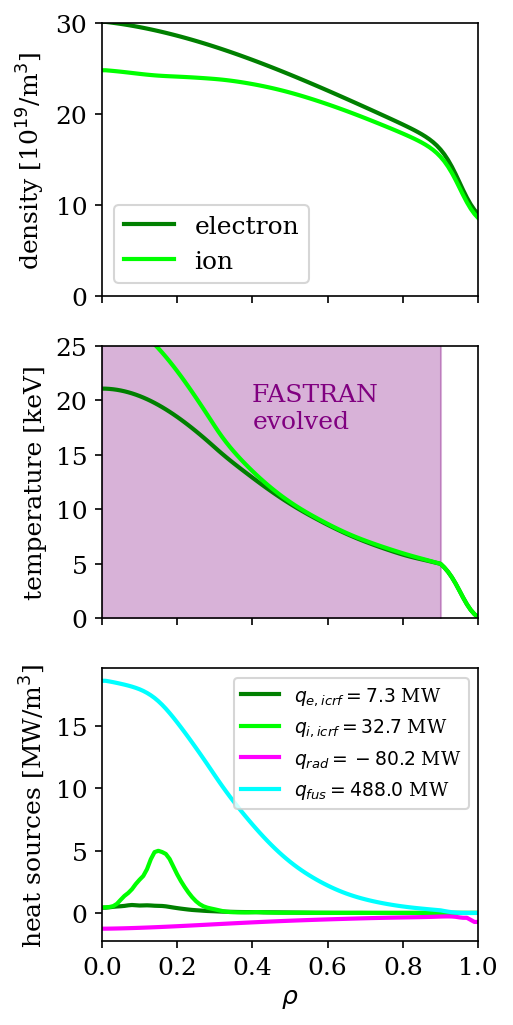

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm

plot_var = 'curr_parallel'

with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    
    fig = plt.figure('fig_offset', figsize=(3.58,7),dpi = 150)
    gs = mpl.gridspec.GridSpec(3,1, figure=fig)
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    axs[2] = fig.add_subplot(gs[1,0],sharex=axs[1])
    axs[3] = fig.add_subplot(gs[2,0],sharex=axs[1])

    
    ax1 = axs[1]
    ax2 = axs[2]
    ax3 = axs[3]

    geqdsk_rho = geqdsk['RHOVN']
    q_prof = geqdsk['fluxSurfaces']['avg']['q']
    for i, q in enumerate(q_prof):
        if np.abs(q-2)< 1e-1:
            q2_index = i
    rho_q2 = geqdsk_rho[q2_index]
    
    # # GET PARAMETERS FROM SCAN FILE
    # param_file = SCAN_dir+'/'+sim+'/'+'parameters.conf'
    # params_table = np.genfromtxt(param_file,dtype=None,usecols=[1,2])

    # param_name_0,param_val_0 = params_table[-1]
    # param_name_1,param_val_1 = params_table[-2]

    
#=====================================================
    rho = rootgrp['rho'][:]
    
    ne = rootgrp['ne'][-1,:]
    nebar = rootgrp['nebar'][-1]
    ni = ni_prof_tot #from above
    te = rootgrp['te'][-1,:]
    teavg = rootgrp['tea'][-1]
    ti = rootgrp['ti'][-1,:]
    tiavg = rootgrp['tia'][-1]
    
    prfe = rootgrp['pe_rf'][-1,:]
    prfe_int = rootgrp['prfe'][-1]
    prfi = rootgrp['pi_rf'][-1,:]
    prfi_int = rootgrp['prfi'][-1]
    
    prad = rootgrp['p_rad'][-1,:]
    prad_int = rootgrp['prad'][-1]
    
    #betan = rootgrp['betan_loc'][-1,:]
    #betan = p_vol_avg*1602.2*2*mu_0/Bt**2#*(aminor*Bt/Ip) ##FIXME doesn't make sense #approximate, check which B to use
    betan_num = rootgrp['betan'][-1]
    
    ipol = rootgrp['ipol'][-1,:]
    ip = rootgrp['ip'][-1]
    
    pfuse = rootgrp['pe_fus'][-1,:]
    pfuse_int = rootgrp['pfuse'][-1]
    pfusi = rootgrp['pi_fus'][-1,:]
    pfusi_int = rootgrp['pfusi'][-1]
    
    q = rootgrp['q'][-1,:]
    
    jbs = rootgrp['j_bs'][-1,:]
    ibs = rootgrp['ibs'][-1]
    jrf = rootgrp['j_rf'][-1,:]
    irf = rootgrp['irf'][-1]
    jtot = rootgrp['j_tot'][-1,:]
    
    fluxe = rootgrp['fluxe'][-1,:]
    fluxe_exp = rootgrp['fluxe_exp'][-1,:]
    fluxi = rootgrp['fluxi'][-1,:]
    fluxi_exp = rootgrp['fluxi_exp'][-1,:]

    #===PLOT================

    ax1.plot(rho,ne,color = c1,linewidth = lw,label='electron')
    ax1.plot(rho,ni,color = c2,linewidth = lw,label='ion')
    ax1.set_ylabel('density [10$^{19}$/m$^3$]')
    ax1.set_xlim(0,1)
    ax1.set_ylim(0,30)
    ax1.legend()
    
    ax2.plot(rho,te,color = c1,linewidth = lw)
    ax2.plot(rho,ti,color = c2,linewidth = lw)
    #ax2.axvline(0.9, color='green', lw=2, alpha=0.7)
    
    ax2.fill_betweenx(np.linspace(-10,max(ti)+10,10), 0, 0.9, color='purple', alpha=0.3)
    ax2.text(0.4,0.7,'FASTRAN \nevolved',color = 'purple',transform=ax2.transAxes)
    ax2.set_ylim(0,25)
    ax2.set_ylabel('temperature [keV]')


    ax3.plot(rho,prfe,color = c1,linewidth = lw,label='$q_{e,icrf} = %.1f$ MW'%(prfe_int))
    ax3.plot(rho,prfi,color = c2,linewidth = lw,label='$q_{i,icrf} = %.1f$ MW'%(prfi_int))
    ax3.plot(rho,prad,color = c3,linewidth = lw,label='$q_{rad} = %.1f$ MW'%(prad_int))
    ax3.plot(rho,5*(pfuse+pfusi),color = c6,linewidth = lw,label='$q_{fus} = %.1f$ MW'%(5*(pfuse_int+pfusi_int)))
    #ax3.text(0.2,0.8,'{:.1f} MW'.format(prad_int),color = c3, transform = ax4.transAxes)
    ax3.set_ylabel('heat sources [MW/m$^3$]')
    ax3.legend(fontsize=9)
    #ax3.text(0.5,0.8,'{:.1f} MW'.format(prfe_int),color = c1, transform = ax3.transAxes)
    #ax3.text(0.5,0.6,'{:.1f} MW'.format(prfi_int),color = c2, transform = ax3.transAxes)
    #ax3.set_ylabel('prad')

    # Make plots share x axis
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    #ax1.text(0.1,0.7,'$\\theta_\\mathrm{grill} = 140^{\\circ}$',transform=ax1.transAxes)
    #ax2.text(0.1,0.7,'$\\theta_\\mathrm{grill} = 180^{\\circ}$',transform=ax2.transAxes)
    #ax3.text(0.1,0.7,'$\\theta_\\mathrm{grill} = 220^{\\circ}$',transform=ax3.transAxes)

    #ax1.text(0.65,0.7,'$N_\\mathrm{||} = -1.7$',color = 'cyan',transform=ax1.transAxes)
    #ax1.text(0.65,0.5,'$N_\\mathrm{||} = -2.0$',color = 'magenta',transform=ax1.transAxes)
    
    #for axis in [ax1,ax2,ax3]:
        #axis.set_xlabel('$\\rho$')
        #axis.axvline(rho_q2)

    ax3.set_xlabel('$\\rho$')
    fig.tight_layout()

    plt.savefig('basecase_profs.pdf',format='pdf',dpi = 300)
    plt.show()


In [38]:
print(q[95])
print(rho[95])

1.9892610290000003
0.9500000000000001


###### print(geqdsk['fluxSurfaces']['avg']['beta_n'])

In [39]:
H98y2 = calc_H98y2(geqdsk,rootgrp)
print(H98y2)

0.9114921763939589


In [40]:
print(ne[85])
print(te[85])

17.75676498
5.408713925774388
